In [1]:
import pandas as pd
import numpy as np

# 1. Load CSV and parse timestamps
df = pd.read_csv('master_broadway_delays.csv')
df['poll_timestamp'] = pd.to_datetime(df['poll_timestamp'])
df['arrival_time'] = pd.to_datetime(df['arrival_time'])

# 2. Filter for Line 51A and get the final arrival timestamp per stop
df_51a = df[df['route_id'] == '51A'].copy()
arrivals = df_51a.groupby(['trip_id', 'stop_name']).agg(
    arrival_time=('arrival_time', 'last')
).reset_index()

# 3. Pivot table so each row is a unique trip and columns are stop names
piv = arrivals.pivot(index='trip_id', columns='stop_name', values='arrival_time')

# 4. Compute block segment travel times in minutes
piv['11th_to_15th'] = (piv['Broadway & 15th St'] - piv['Broadway & 11th St (12th St BART)']).dt.total_seconds() / 60.0
piv['15th_to_17th'] = (piv['Broadway & 17th St'] - piv['Broadway & 15th St']).dt.total_seconds() / 60.0
piv['17th_to_20th'] = (piv['Broadway & 20th St (19th St BART)'] - piv['Broadway & 17th St']).dt.total_seconds() / 60.0
piv['20th_to_Grand'] = (piv['Broadway & Grand Av'] - piv['Broadway & 20th St (19th St BART)']).dt.total_seconds() / 60.0

# 5. Assign time windows based on hour of the day
piv['hour'] = piv['Broadway & 15th St'].dt.hour
piv['time_window'] = piv['hour'].apply(
    lambda h: 'Off-Peak Baseline (12 AM & 5 AM)' if 0 <= h <= 5
    else ('Daytime Peak (7 AM-5 PM)' if 7 <= h <= 17 else 'Evening (6-11 PM)')
)

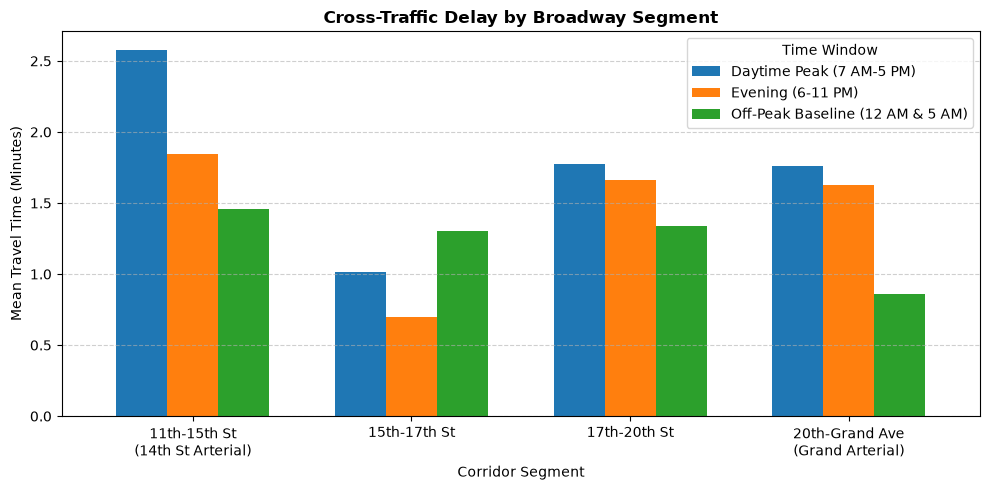

In [2]:
import matplotlib.pyplot as plt

# Group by time window and calculate segment averages
segment_cols = ['11th_to_15th', '15th_to_17th', '17th_to_20th', '20th_to_Grand']
seg_means = piv.groupby('time_window')[segment_cols].mean().T

# Create grouped bar plot
ax = seg_means.plot(kind='bar', figsize=(10, 5), width=0.7)
plt.title('Cross-Traffic Delay by Broadway Segment', fontsize=12, fontweight='bold')
plt.ylabel('Mean Travel Time (Minutes)')
plt.xlabel('Corridor Segment')
plt.xticks(range(4), ['11th-15th St\n(14th St Arterial)', '15th-17th St', '17th-20th St', '20th-Grand Ave\n(Grand Arterial)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Time Window')
plt.tight_layout()
plt.savefig("figure1_daytime_bottlenecks.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
%pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/z1/7znscskx435088f0cpk19mbm0000gn/T/ipykernel_50715/2812725667.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_hw, x='time_window', y='headway_min', palette='Set2')


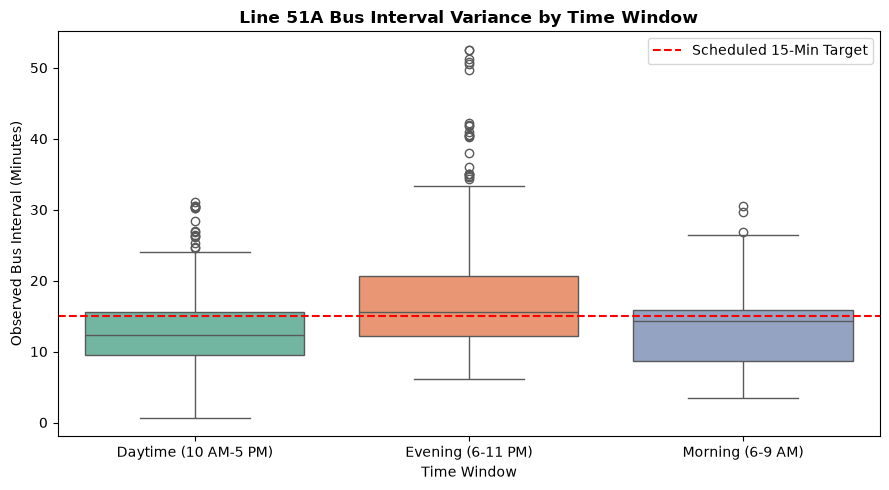

In [4]:
import seaborn as sns

# Sort arrivals by stop and timestamp
arrivals_sorted = df_51a.groupby(['trip_id', 'stop_name', 'stop_id']).agg(
    final_predicted=('arrival_time', 'last')
).reset_index().sort_values(['stop_name', 'final_predicted'])

# Compute difference between consecutive arrivals at the same stop
arrivals_sorted['prev_arrival'] = arrivals_sorted.groupby('stop_name')['final_predicted'].shift(1)
arrivals_sorted['headway_min'] = (arrivals_sorted['final_predicted'] - arrivals_sorted['prev_arrival']).dt.total_seconds() / 60.0

# Filter realistic range (0.5 to 60 mins)
valid_hw = arrivals_sorted[(arrivals_sorted['headway_min'] >= 0.5) & (arrivals_sorted['headway_min'] <= 60)].copy()

# Add time window column
valid_hw['time_window'] = valid_hw['final_predicted'].dt.hour.apply(
    lambda h: 'Morning (6-9 AM)' if 6 <= h <= 9 else ('Daytime (10 AM-5 PM)' if 10 <= h <= 17 else 'Evening (6-11 PM)')
)

# Plot boxplot showing distribution of arrival intervals
plt.figure(figsize=(9, 5))
sns.boxplot(data=valid_hw, x='time_window', y='headway_min', palette='Set2')
plt.axhline(15, color='red', linestyle='--', label='Scheduled 15-Min Target')
plt.title('Line 51A Bus Interval Variance by Time Window', fontsize=12, fontweight='bold')
plt.ylabel('Observed Bus Interval (Minutes)')
plt.xlabel('Time Window')
plt.legend()
plt.tight_layout()
plt.savefig("figure2_evening_headways.png", dpi=300, bbox_inches='tight')
plt.show()